In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

print("All libraries loaded!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


All libraries loaded!


[nltk_data]   Unzipping tokenizers\punkt.zip.


In [5]:
df = pd.read_csv('Resume.csv')
print("Shape:", df.shape)
df.head()

Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
df.columns
df['Category'].nunique()
df['Category'].value_counts()


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_17128\2911361086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


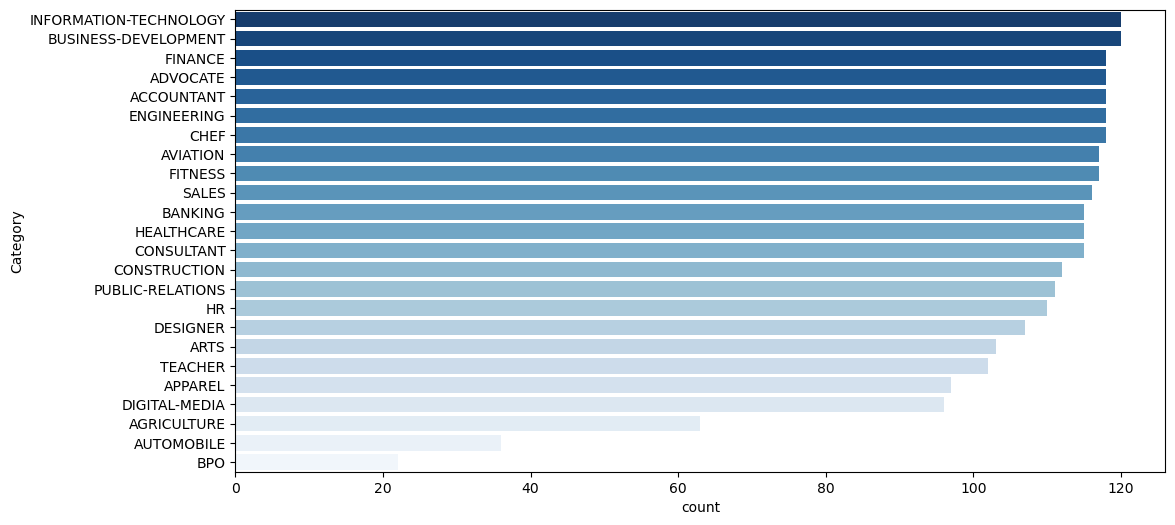

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y='Category',
    order=df['Category'].value_counts().index,
    palette='Blues_r'
)
plt.show()

In [18]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_resume'] = df['Resume_str'].apply(clean_text)
print(df['Resume_str'].iloc[0][:200])
print(df['clean_resume'].iloc[0][:200])


         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp
hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams 


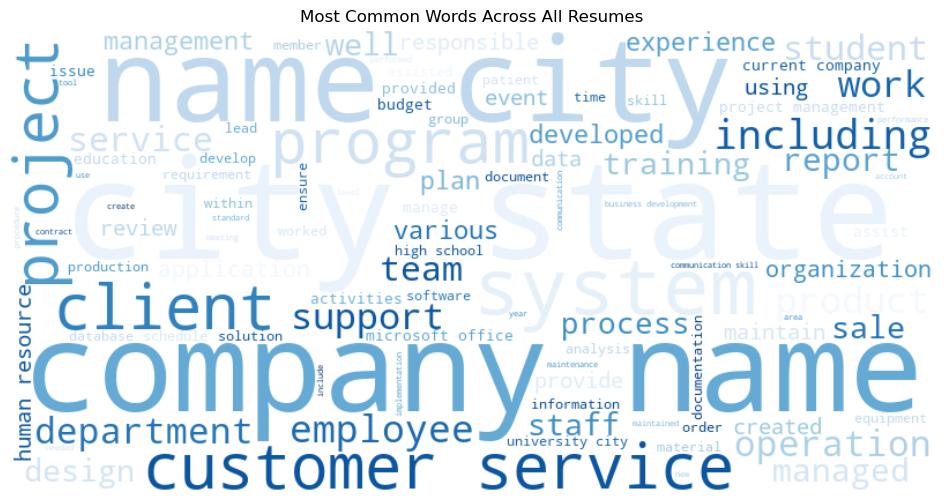

In [19]:
all_text = ' '.join(df['clean_resume'].values)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='Blues'
).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words Across All Resumes')
plt.show()

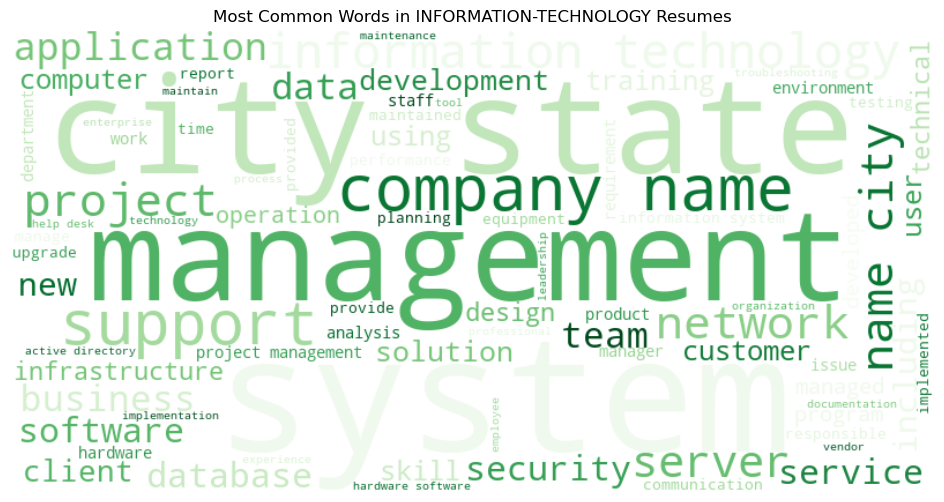

In [20]:
category = 'INFORMATION-TECHNOLOGY'
category_text = ' '.join(df[df['Category'] == category]['clean_resume'].values)

wordcloud_cat = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=80,
    colormap='Greens'
).generate(category_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud_cat, interpolation='bilinear')
plt.axis('off')
plt.title(f'Most Common Words in {category} Resumes')
plt.show()